1

In [55]:
import pandas as pd
import sqlite3

2

In [56]:
cnx = sqlite3.connect('../../datasets/checking-logs.sqlite')
df = pd.read_sql('SELECT * FROM pageviews;', cnx)
query = '''
SELECT uid, datetime FROM pageviews
WHERE uid NOT LIKE '%admin%'
'''
df_pageviews = pd.read_sql(query, cnx)
print(df_pageviews)

         uid                    datetime
0    user_30  2020-04-17 22:46:26.785035
1    user_14  2020-04-18 10:53:52.623447
2    user_17  2020-04-18 10:56:55.833899
3    user_14  2020-04-18 10:57:37.331258
4    user_17  2020-04-18 12:05:48.200144
..       ...                         ...
982  user_28  2020-05-21 18:45:20.441142
983  user_19  2020-05-21 23:03:06.457819
984  user_25  2020-05-21 23:23:49.995349
985   user_5  2020-05-22 11:30:18.368990
986  user_17  2020-05-22 18:22:22.847815

[987 rows x 2 columns]


3

In [57]:
df_pageviews["datetime"] = pd.to_datetime(df_pageviews["datetime"])
df_pageviews["date"] = df_pageviews["datetime"].dt.date

df_grouped = df_pageviews.groupby("date").size().reset_index(name="views")

print(df_grouped)


          date  views
0   2020-04-17      1
1   2020-04-18     23
2   2020-04-19     15
3   2020-04-21      3
4   2020-04-22      1
5   2020-04-23      5
6   2020-04-25      1
7   2020-04-26      8
8   2020-04-28      2
9   2020-04-29      4
10  2020-04-30      9
11  2020-05-01      3
12  2020-05-02      6
13  2020-05-03     19
14  2020-05-04      1
15  2020-05-05      1
16  2020-05-06      3
17  2020-05-07      2
18  2020-05-08     48
19  2020-05-09     19
20  2020-05-10    110
21  2020-05-11    200
22  2020-05-12     85
23  2020-05-13    102
24  2020-05-14    187
25  2020-05-15     29
26  2020-05-16      4
27  2020-05-17      9
28  2020-05-18     51
29  2020-05-19     11
30  2020-05-20     12
31  2020-05-21     11
32  2020-05-22      2


4

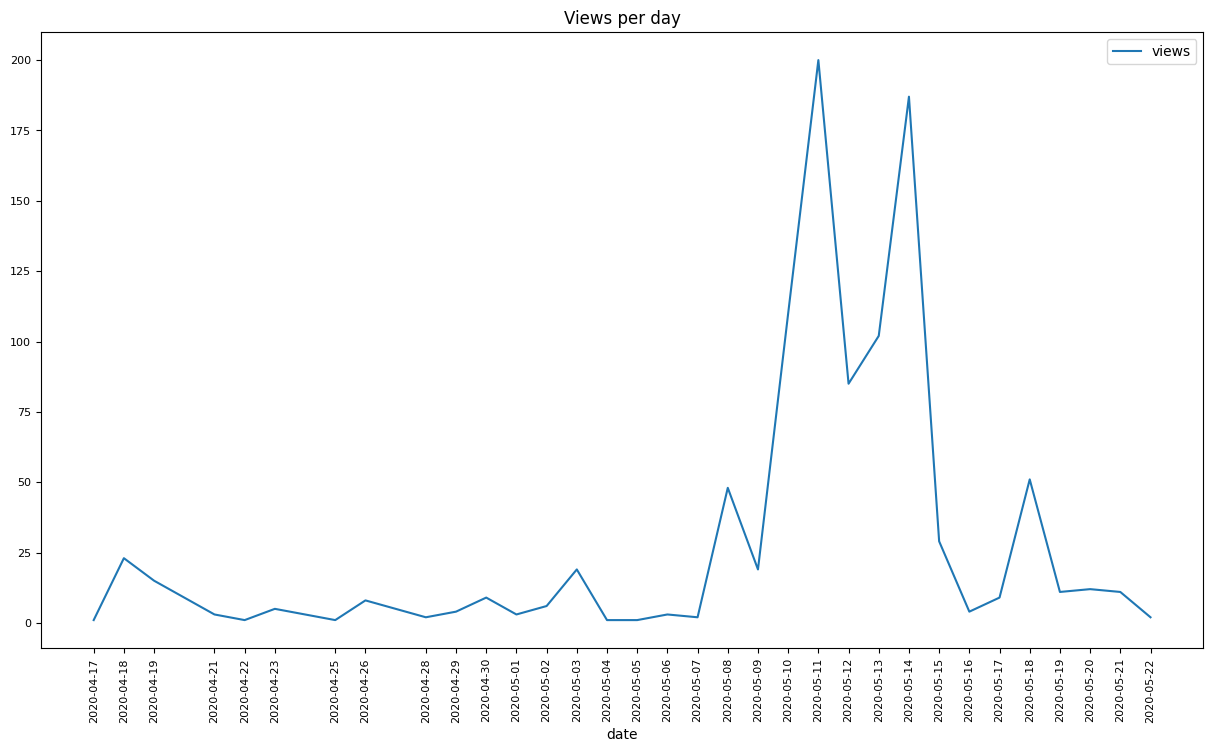

In [62]:
graph = df_grouped.plot(x="date", y="views", figsize=(15, 8), title="Views per day", fontsize=8)
graph.set_xticks(df_grouped["date"])
graph.set_xticklabels(df_grouped["date"], rotation=90)
cnx.close()